# Support Vector Machine (SVM)

## Overview
Support Vector Machine finds the **optimal hyperplane** that separates classes with the **maximum margin**. The data points closest to the decision boundary are called **support vectors** — they are the only points that determine the hyperplane.

### Hard Margin (linearly separable):
$$\text{Maximize} \quad \frac{2}{\|\mathbf{w}\|} \quad \text{subject to} \quad y_i(\mathbf{w}^T x_i + b) \geq 1$$

### Soft Margin (with slack variables $\xi_i$):
$$\text{Minimize} \quad \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^{n}\xi_i$$

### Kernel Trick (non-linear boundaries):
$$K(x_i, x_j) = \phi(x_i)^T \phi(x_j)$$

| Kernel | Formula | Use Case |
|--------|---------|----------|
| Linear | $x_i^T x_j$ | Linearly separable data |
| RBF (Gaussian) | $\exp(-\gamma\|x_i - x_j\|^2)$ | Non-linear, general purpose |
| Polynomial | $(x_i^T x_j + r)^d$ | Polynomial relationships |
| Sigmoid | $\tanh(\gamma x_i^T x_j + r)$ | Neural-net-like boundary |

---
### Topics Covered
1. Maximum margin intuition
2. Linear SVM — hard and soft margin
3. Effect of C (regularization)
4. Kernel trick — RBF, Polynomial, Sigmoid
5. Effect of gamma on RBF kernel
6. Support vectors visualization
7. Hyperparameter tuning with GridSearchCV
8. SVM for Regression (SVR)
9. Real-world offline-safe dataset
10. Full model evaluation


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay,
    mean_squared_error, r2_score, mean_absolute_error
)
from sklearn.datasets import make_classification, make_circles, make_moons

COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#E67E22',
    'tertiary':  '#9B59B6',
    'success':   '#27AE60',
    'danger':    '#E74C3C',
    'neutral':   '#7F8C8D',
}

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Libraries imported successfully!
NumPy  : 1.26.4
Pandas : 2.3.3


## 2. Maximum Margin Intuition

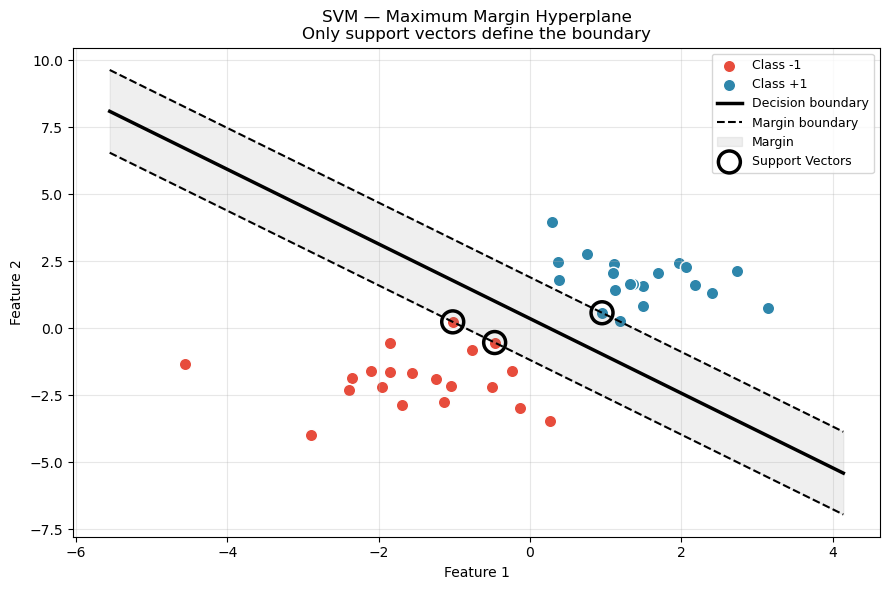

Number of support vectors : 3
Margin width              : 1.8002
Hyperplane (w, b)         : w=[0.9023 0.6482], b=-0.2345


In [2]:
np.random.seed(0)
# Simple 2D linearly separable data
X_lin = np.r_[np.random.randn(20, 2) - [2, 2],
               np.random.randn(20, 2) + [2, 2]]
y_lin = np.array([-1]*20 + [1]*20)

svm_lin = SVC(kernel='linear', C=1e6)   # very large C -> hard margin
svm_lin.fit(X_lin, y_lin)

w   = svm_lin.coef_[0]
b   = svm_lin.intercept_[0]
xx  = np.linspace(X_lin[:, 0].min()-1, X_lin[:, 0].max()+1, 200)

# Decision boundary and margins
decision = -w[0]/w[1] * xx - b/w[1]
margin_p  = decision + 1/w[1]
margin_n  = decision - 1/w[1]

plt.figure(figsize=(9, 6))
plt.scatter(X_lin[y_lin==-1, 0], X_lin[y_lin==-1, 1],
            color=COLORS['danger'],  edgecolors='white', s=80, label='Class -1')
plt.scatter(X_lin[y_lin== 1, 0], X_lin[y_lin== 1, 1],
            color=COLORS['primary'], edgecolors='white', s=80, label='Class +1')
plt.plot(xx, decision, 'k-',  linewidth=2.5, label='Decision boundary')
plt.plot(xx, margin_p, 'k--', linewidth=1.5, label='Margin boundary')
plt.plot(xx, margin_n, 'k--', linewidth=1.5)
plt.fill_between(xx, margin_n, margin_p, alpha=0.12, color='gray', label='Margin')

# Highlight support vectors
svs = svm_lin.support_vectors_
plt.scatter(svs[:, 0], svs[:, 1], s=250, facecolors='none',
            edgecolors='black', linewidths=2.5, label='Support Vectors', zorder=5)

plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('SVM — Maximum Margin Hyperplane\nOnly support vectors define the boundary')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

margin_width = 2 / np.linalg.norm(w)
print(f'Number of support vectors : {len(svs)}')
print(f'Margin width              : {margin_width:.4f}')
print(f'Hyperplane (w, b)         : w={w.round(4)}, b={b:.4f}')

## 3. Soft Margin — Effect of C (Regularization)

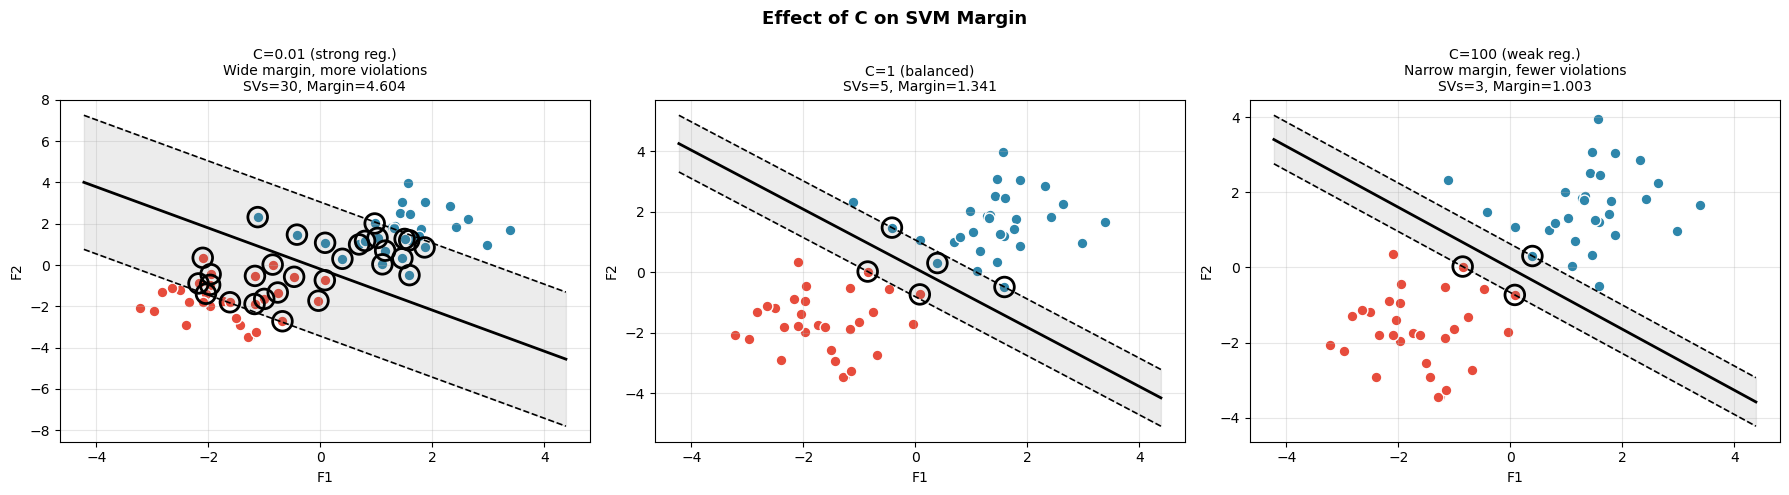

Small C -> wide margin, allows more misclassifications (regularized)
Large C -> narrow margin, tries to classify all points correctly (may overfit)


In [3]:
np.random.seed(42)
X_soft = np.r_[np.random.randn(30, 2) - [1.5, 1.5],
                np.random.randn(30, 2) + [1.5, 1.5]]
y_soft = np.array([-1]*30 + [1]*30)

C_values  = [0.01, 1, 100]
titles    = ['C=0.01 (strong reg.)\nWide margin, more violations',
             'C=1 (balanced)',
             'C=100 (weak reg.)\nNarrow margin, fewer violations']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_range   = np.linspace(X_soft[:, 0].min()-1, X_soft[:, 0].max()+1, 200)

for ax, C, title in zip(axes, C_values, titles):
    clf = SVC(kernel='linear', C=C)
    clf.fit(X_soft, y_soft)
    w2, b2 = clf.coef_[0], clf.intercept_[0]

    dec = -w2[0]/w2[1]*x_range - b2/w2[1]
    mp  = dec + 1/w2[1]
    mn  = dec - 1/w2[1]

    ax.scatter(X_soft[y_soft==-1, 0], X_soft[y_soft==-1, 1],
               color=COLORS['danger'],  edgecolors='white', s=60)
    ax.scatter(X_soft[y_soft== 1, 0], X_soft[y_soft== 1, 1],
               color=COLORS['primary'], edgecolors='white', s=60)
    ax.plot(x_range, dec, 'k-',  linewidth=2)
    ax.plot(x_range, mp,  'k--', linewidth=1.2)
    ax.plot(x_range, mn,  'k--', linewidth=1.2)
    ax.fill_between(x_range, mn, mp, alpha=0.15, color='gray')
    svs2 = clf.support_vectors_
    ax.scatter(svs2[:, 0], svs2[:, 1], s=200, facecolors='none',
               edgecolors='black', linewidths=2, zorder=5)
    mw = 2 / np.linalg.norm(w2)
    ax.set_title(f'{title}\nSVs={len(svs2)}, Margin={mw:.3f}', fontsize=10)
    ax.set_xlabel('F1'); ax.set_ylabel('F2')

plt.suptitle('Effect of C on SVM Margin', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Small C -> wide margin, allows more misclassifications (regularized)')
print('Large C -> narrow margin, tries to classify all points correctly (may overfit)')

## 4. Kernel Trick — Handling Non-Linear Data

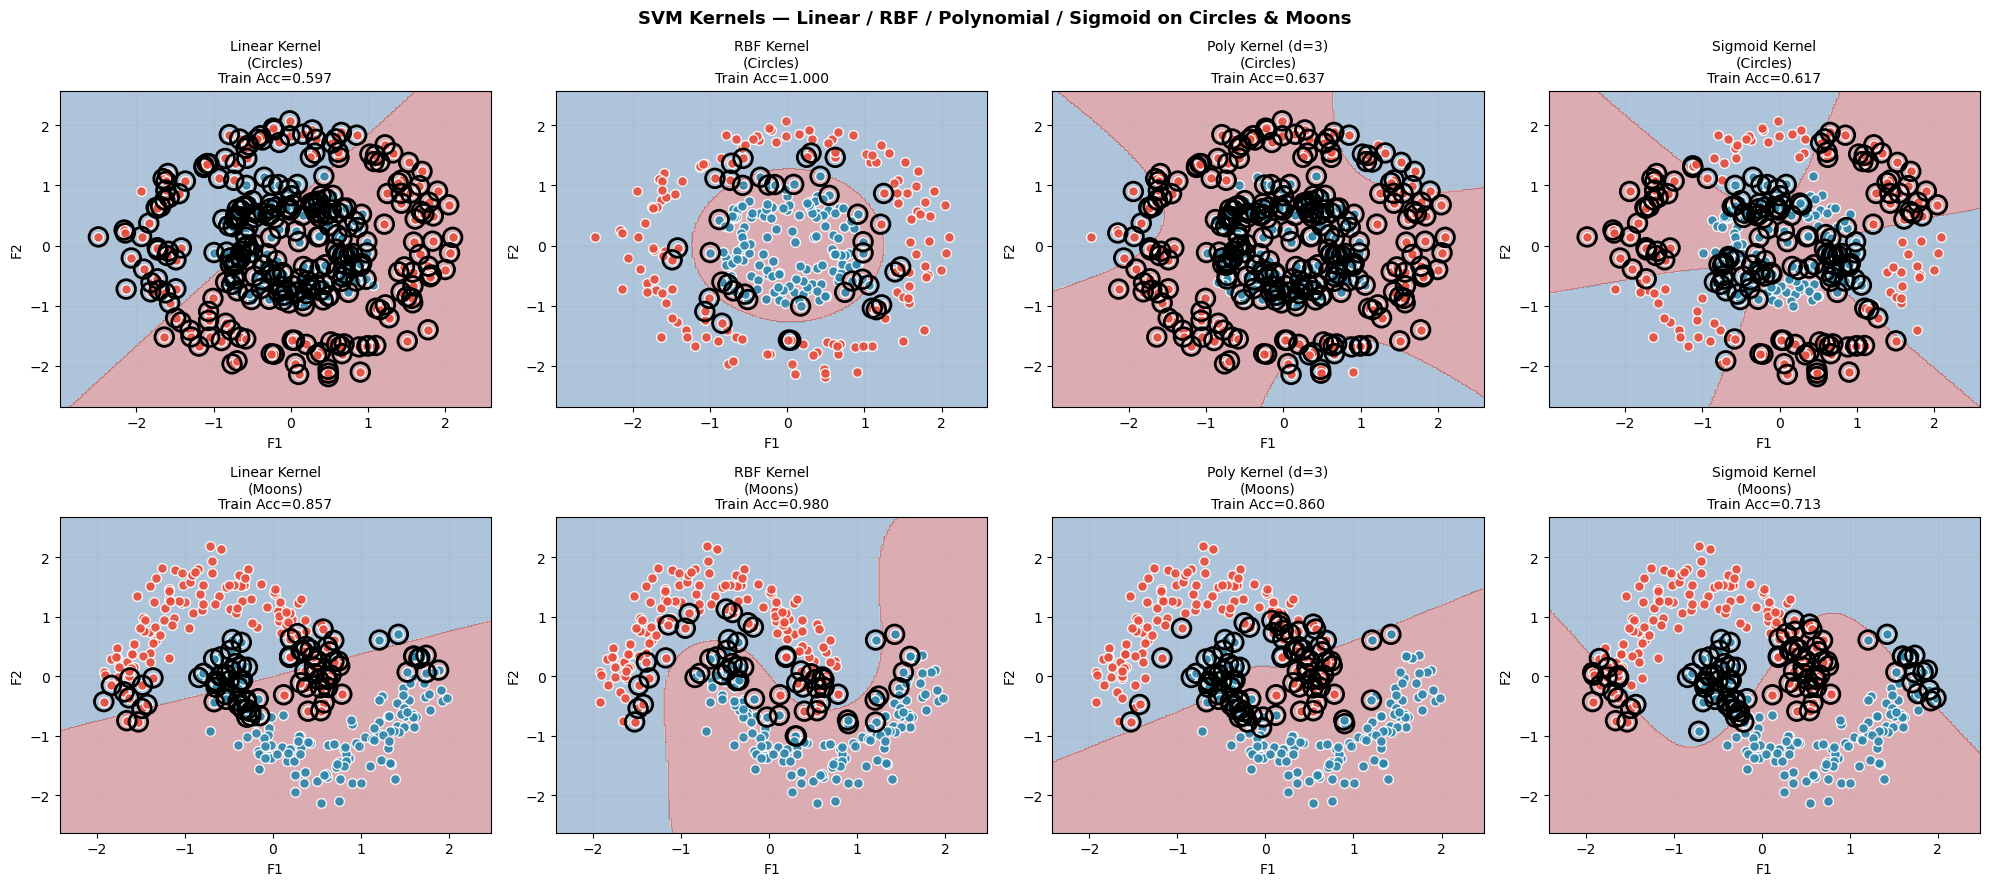

In [4]:
def plot_svm_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min()-0.5, X[:, 0].max()+0.5
    y_min, y_max = X[:, 1].min()-0.5, X[:, 1].max()+0.5
    xx_, yy_ = np.meshgrid(np.linspace(x_min, x_max, 300),
                            np.linspace(y_min, y_max, 300))
    Z_ = model.predict(np.c_[xx_.ravel(), yy_.ravel()]).reshape(xx_.shape)
    ax.contourf(xx_, yy_, Z_, alpha=0.35, cmap='RdBu_r')
    ax.scatter(X[y==0, 0], X[y==0, 1], color=COLORS['danger'],
               edgecolors='white', s=50, alpha=0.9)
    ax.scatter(X[y==1, 0], X[y==1, 1], color=COLORS['primary'],
               edgecolors='white', s=50, alpha=0.9)
    svs_ = model.support_vectors_
    ax.scatter(svs_[:, 0], svs_[:, 1], s=180, facecolors='none',
               edgecolors='black', linewidths=2, zorder=5)
    acc = accuracy_score(y, model.predict(X))
    ax.set_title(f'{title}\nTrain Acc={acc:.3f}', fontsize=10)
    ax.set_xlabel('F1'); ax.set_ylabel('F2')

# Circles dataset — clearly non-linear
np.random.seed(5)
X_circ, y_circ = make_circles(n_samples=300, noise=0.12, factor=0.4, random_state=5)
X_moon, y_moon = make_moons(n_samples=300, noise=0.15, random_state=5)

kernels = [
    ('linear',  {'C': 1},                          'Linear Kernel'),
    ('rbf',     {'C': 1, 'gamma': 'scale'},        'RBF Kernel'),
    ('poly',    {'C': 1, 'degree': 3, 'gamma': 'scale'}, 'Poly Kernel (d=3)'),
    ('sigmoid', {'C': 1, 'gamma': 'scale'},        'Sigmoid Kernel'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for col, (kernel, params, title) in enumerate(kernels):
    for row, (X_k, y_k, ds) in enumerate([
        (X_circ, y_circ, 'Circles'),
        (X_moon, y_moon, 'Moons')
    ]):
        scaler_k = StandardScaler()
        X_k_sc   = scaler_k.fit_transform(X_k)
        clf_k    = SVC(kernel=kernel, **params)
        clf_k.fit(X_k_sc, y_k)
        plot_svm_boundary(axes[row][col], clf_k, X_k_sc, y_k,
                          f'{title}\n({ds})')

plt.suptitle('SVM Kernels — Linear / RBF / Polynomial / Sigmoid on Circles & Moons',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Effect of Gamma on RBF Kernel

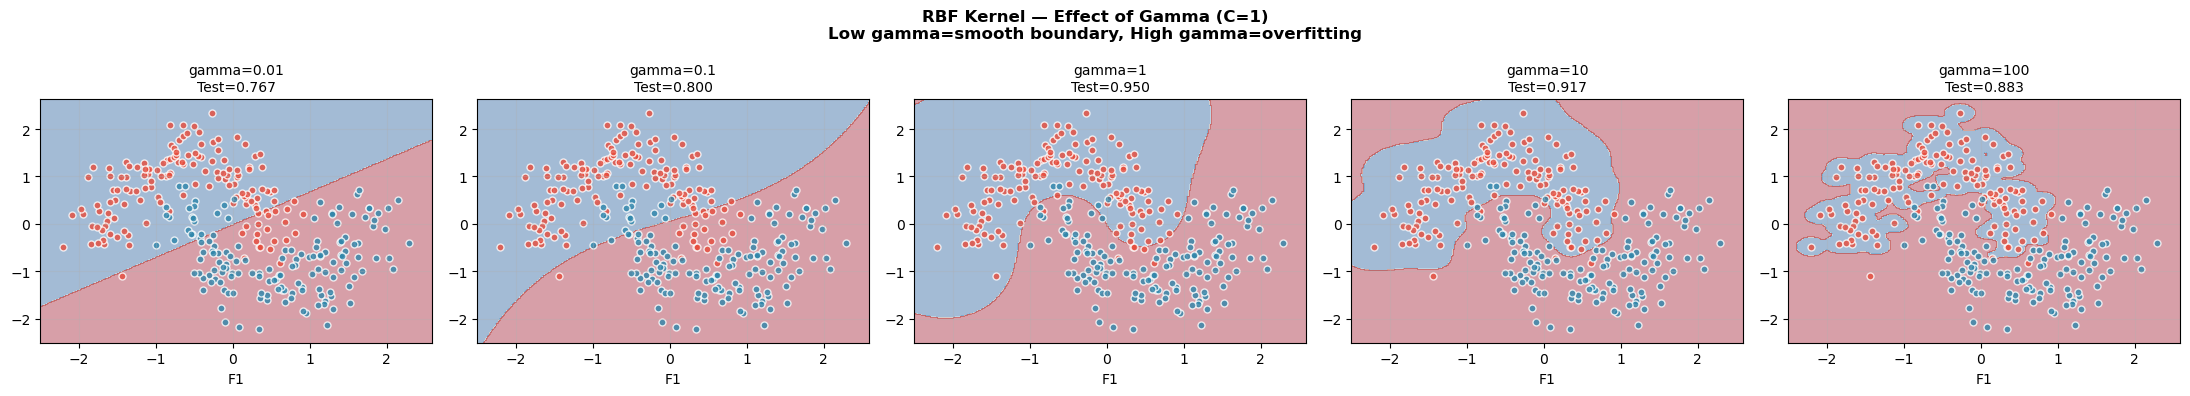

Low gamma  -> large influence radius -> smooth, underfitting boundary
High gamma -> small influence radius -> wiggly, overfitting boundary


In [5]:
np.random.seed(42)
X_g, y_g = make_moons(n_samples=300, noise=0.2, random_state=42)
sc_g      = StandardScaler()
X_g_sc    = sc_g.fit_transform(X_g)

X_g_tr, X_g_te, y_g_tr, y_g_te = train_test_split(
    X_g_sc, y_g, test_size=0.2, random_state=42, stratify=y_g
)

gammas = [0.01, 0.1, 1, 10, 100]
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

x_min, x_max = X_g_sc[:, 0].min()-0.3, X_g_sc[:, 0].max()+0.3
y_min, y_max = X_g_sc[:, 1].min()-0.3, X_g_sc[:, 1].max()+0.3
xx_g, yy_g   = np.meshgrid(np.linspace(x_min, x_max, 300),
                             np.linspace(y_min, y_max, 300))

for ax, gamma in zip(axes, gammas):
    clf_g = SVC(kernel='rbf', C=1, gamma=gamma)
    clf_g.fit(X_g_tr, y_g_tr)
    Z_g = clf_g.predict(np.c_[xx_g.ravel(), yy_g.ravel()]).reshape(xx_g.shape)
    test_acc = accuracy_score(y_g_te, clf_g.predict(X_g_te))

    ax.contourf(xx_g, yy_g, Z_g, alpha=0.4, cmap='RdBu_r')
    ax.scatter(X_g_sc[y_g==0, 0], X_g_sc[y_g==0, 1],
               color=COLORS['danger'],  s=25, alpha=0.8, edgecolors='white')
    ax.scatter(X_g_sc[y_g==1, 0], X_g_sc[y_g==1, 1],
               color=COLORS['primary'], s=25, alpha=0.8, edgecolors='white')
    ax.set_title(f'gamma={gamma}\nTest={test_acc:.3f}', fontsize=10)
    ax.set_xlabel('F1')

plt.suptitle('RBF Kernel — Effect of Gamma (C=1)\nLow gamma=smooth boundary, High gamma=overfitting',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Low gamma  -> large influence radius -> smooth, underfitting boundary')
print('High gamma -> small influence radius -> wiggly, overfitting boundary')

## 6. Full Classification Dataset & Support Vectors

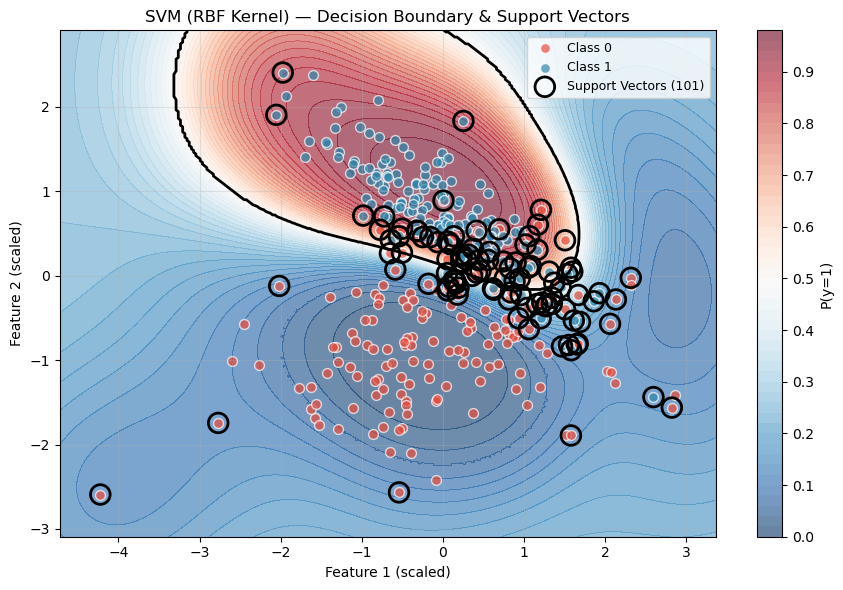

Total support vectors : 101 / 320 training samples
Test Accuracy         : 0.8250
Test ROC-AUC          : 0.9150


In [6]:
np.random.seed(42)
X_cls, y_cls = make_classification(
    n_samples=400, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.0, random_state=42
)

X_cls_tr, X_cls_te, y_cls_tr, y_cls_te = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

sc_cls    = StandardScaler()
X_cls_tr_sc = sc_cls.fit_transform(X_cls_tr)
X_cls_te_sc = sc_cls.transform(X_cls_te)

svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_rbf.fit(X_cls_tr_sc, y_cls_tr)

y_cls_pred = svm_rbf.predict(X_cls_te_sc)
y_cls_prob = svm_rbf.predict_proba(X_cls_te_sc)[:, 1]

x0_min, x0_max = X_cls_tr_sc[:, 0].min()-0.5, X_cls_tr_sc[:, 0].max()+0.5
x1_min, x1_max = X_cls_tr_sc[:, 1].min()-0.5, X_cls_tr_sc[:, 1].max()+0.5
xx_c, yy_c = np.meshgrid(np.linspace(x0_min, x0_max, 300),
                          np.linspace(x1_min, x1_max, 300))
Z_c = svm_rbf.predict_proba(np.c_[xx_c.ravel(), yy_c.ravel()])[:, 1].reshape(xx_c.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx_c, yy_c, Z_c, levels=50, cmap='RdBu_r', alpha=0.6)
plt.colorbar(label='P(y=1)')
plt.contour(xx_c, yy_c, Z_c, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X_cls_tr_sc[y_cls_tr==0, 0], X_cls_tr_sc[y_cls_tr==0, 1],
            color=COLORS['danger'],  edgecolors='white', s=50, alpha=0.7, label='Class 0')
plt.scatter(X_cls_tr_sc[y_cls_tr==1, 0], X_cls_tr_sc[y_cls_tr==1, 1],
            color=COLORS['primary'], edgecolors='white', s=50, alpha=0.7, label='Class 1')
svs_rbf = svm_rbf.support_vectors_
plt.scatter(svs_rbf[:, 0], svs_rbf[:, 1], s=200, facecolors='none',
            edgecolors='black', linewidths=2, zorder=5, label=f'Support Vectors ({len(svs_rbf)})')
plt.xlabel('Feature 1 (scaled)'); plt.ylabel('Feature 2 (scaled)')
plt.title('SVM (RBF Kernel) — Decision Boundary & Support Vectors')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Total support vectors : {len(svs_rbf)} / {len(X_cls_tr_sc)} training samples')
print(f'Test Accuracy         : {accuracy_score(y_cls_te, y_cls_pred):.4f}')
print(f'Test ROC-AUC          : {roc_auc_score(y_cls_te, y_cls_prob):.4f}')

## 7. Model Evaluation

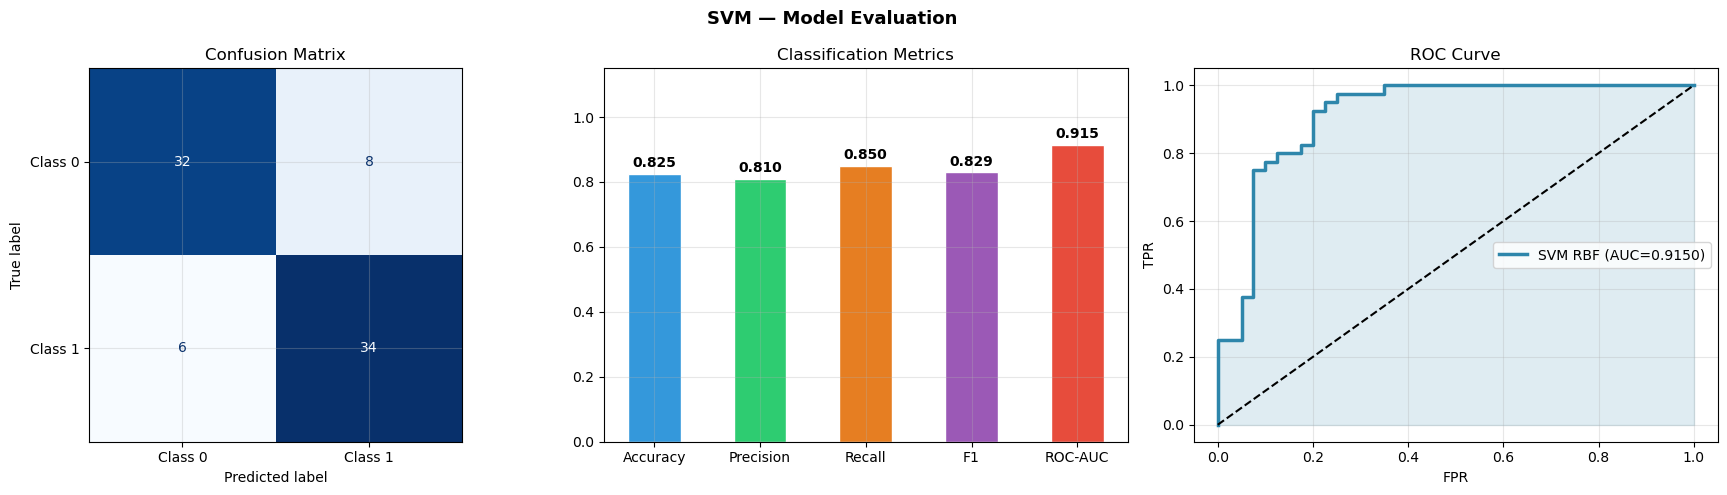

              precision    recall  f1-score   support

     Class 0       0.84      0.80      0.82        40
     Class 1       0.81      0.85      0.83        40

    accuracy                           0.82        80
   macro avg       0.83      0.82      0.82        80
weighted avg       0.83      0.82      0.82        80



In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm_cls = confusion_matrix(y_cls_te, y_cls_pred)
ConfusionMatrixDisplay(cm_cls, display_labels=['Class 0','Class 1']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix')

# Metrics bar
metrics = {
    'Accuracy':  accuracy_score(y_cls_te, y_cls_pred),
    'Precision': precision_score(y_cls_te, y_cls_pred),
    'Recall':    recall_score(y_cls_te, y_cls_pred),
    'F1':        f1_score(y_cls_te, y_cls_pred),
    'ROC-AUC':   roc_auc_score(y_cls_te, y_cls_prob),
}
colors_m = ['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c']
bars = axes[1].bar(metrics.keys(), metrics.values(), color=colors_m,
                   edgecolor='white', width=0.5)
axes[1].set_ylim(0, 1.15)
for bar, val in zip(bars, metrics.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{val:.3f}', ha='center', fontweight='bold')
axes[1].set_title('Classification Metrics')

# ROC curve
fpr, tpr, _ = roc_curve(y_cls_te, y_cls_prob)
auc_val     = roc_auc_score(y_cls_te, y_cls_prob)
axes[2].plot(fpr, tpr, color=COLORS['primary'], linewidth=2.5,
             label=f'SVM RBF (AUC={auc_val:.4f})')
axes[2].plot([0,1],[0,1],'k--', linewidth=1.5)
axes[2].fill_between(fpr, tpr, alpha=0.15, color=COLORS['primary'])
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('ROC Curve')
axes[2].legend()

plt.suptitle('SVM — Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(classification_report(y_cls_te, y_cls_pred, target_names=['Class 0','Class 1']))

## 8. Hyperparameter Tuning — GridSearchCV (C & gamma)

Best params   : {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV AUC   : 0.9641
Test Accuracy : 0.8625
Test ROC-AUC  : 0.9437


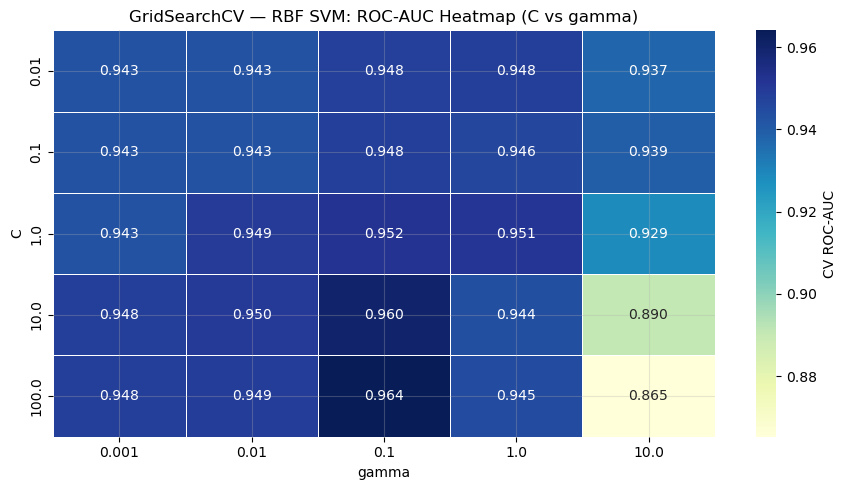

In [8]:
param_grid = {
    'C':     [0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10],
    'kernel': ['rbf'],
}

grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_cls_tr_sc, y_cls_tr)

print(f'Best params   : {grid.best_params_}')
print(f'Best CV AUC   : {grid.best_score_:.4f}')

best_svm  = grid.best_estimator_
bp        = best_svm.predict(X_cls_te_sc)
bprob     = best_svm.predict_proba(X_cls_te_sc)[:, 1]
print(f'Test Accuracy : {accuracy_score(y_cls_te, bp):.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_cls_te, bprob):.4f}')

# Heatmap of CV scores over C x gamma
cv_df = pd.DataFrame(grid.cv_results_)
pivot = cv_df.pivot_table(
    index='param_C', columns='param_gamma', values='mean_test_score'
)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'CV ROC-AUC'})
plt.xlabel('gamma'); plt.ylabel('C')
plt.title('GridSearchCV — RBF SVM: ROC-AUC Heatmap (C vs gamma)')
plt.tight_layout()
plt.show()

## 9. Support Vector Regression (SVR)

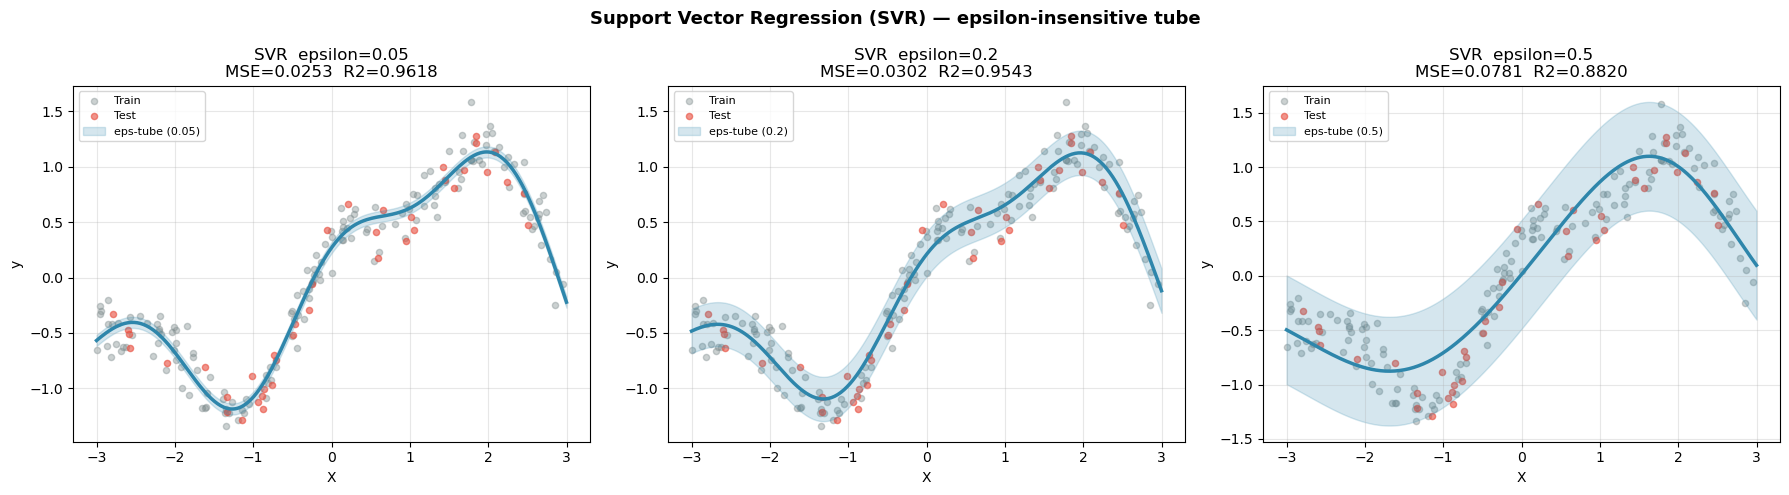

SVR ignores errors within the epsilon-tube (the gray band).
Only points OUTSIDE the tube become support vectors and affect the model.
Smaller epsilon -> more support vectors, tighter fit.


In [9]:
np.random.seed(7)
X_svr = np.sort(np.random.uniform(-3, 3, 200)).reshape(-1, 1)
y_svr = np.sin(X_svr).ravel() + 0.3*np.cos(3*X_svr).ravel() + np.random.randn(200)*0.15

X_svr_tr, X_svr_te, y_svr_tr, y_svr_te = train_test_split(
    X_svr, y_svr, test_size=0.2, random_state=42
)

sc_svr    = StandardScaler()
X_svr_tr_sc = sc_svr.fit_transform(X_svr_tr)
X_svr_te_sc = sc_svr.transform(X_svr_te)

epsilons  = [0.05, 0.2, 0.5]
X_plot_r  = np.linspace(-3, 3, 300).reshape(-1, 1)
X_plot_sc = sc_svr.transform(X_plot_r)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, eps in zip(axes, epsilons):
    svr = SVR(kernel='rbf', C=10, gamma='scale', epsilon=eps)
    svr.fit(X_svr_tr_sc, y_svr_tr)
    y_plot_svr = svr.predict(X_plot_sc)
    test_mse   = mean_squared_error(y_svr_te, svr.predict(X_svr_te_sc))
    test_r2    = r2_score(y_svr_te, svr.predict(X_svr_te_sc))

    ax.scatter(X_svr_tr, y_svr_tr, alpha=0.4, s=20, color=COLORS['neutral'], label='Train')
    ax.scatter(X_svr_te, y_svr_te, alpha=0.6, s=20, color=COLORS['danger'],  label='Test')
    ax.plot(X_plot_r, y_plot_svr, color=COLORS['primary'], linewidth=2.5)
    ax.fill_between(X_plot_r.ravel(),
                    y_plot_svr - eps, y_plot_svr + eps,
                    alpha=0.2, color=COLORS['primary'], label=f'eps-tube ({eps})')
    ax.set_title(f'SVR  epsilon={eps}\nMSE={test_mse:.4f}  R2={test_r2:.4f}')
    ax.set_xlabel('X'); ax.set_ylabel('y')
    ax.legend(fontsize=8)

plt.suptitle('Support Vector Regression (SVR) — epsilon-insensitive tube',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('SVR ignores errors within the epsilon-tube (the gray band).')
print('Only points OUTSIDE the tube become support vectors and affect the model.')
print('Smaller epsilon -> more support vectors, tighter fit.')

## 10. Real-World Offline-Safe Dataset — Disease Severity Prediction

In [10]:
np.random.seed(99)
n_med = 900

Age          = np.random.randint(20, 80, n_med).astype(float)
BMI          = np.random.uniform(18, 45, n_med)
BloodPres    = np.random.uniform(60, 140, n_med)
Glucose      = np.random.uniform(70, 200, n_med)
Cholesterol  = np.random.uniform(150, 350, n_med)
Insulin      = np.random.uniform(10, 300, n_med)
HeartRate    = np.random.uniform(50, 110, n_med)
CRP          = np.random.uniform(0, 10, n_med)   # C-reactive protein

feat_names_med = ['Age','BMI','BloodPres','Glucose',
                  'Cholesterol','Insulin','HeartRate','CRP']
X_med = np.column_stack([Age, BMI, BloodPres, Glucose,
                          Cholesterol, Insulin, HeartRate, CRP])

log_odds = (-4 + 0.03*Age + 0.08*BMI + 0.02*BloodPres
            + 0.02*Glucose + 0.005*Cholesterol + 0.2*CRP)
prob_dis = 1 / (1 + np.exp(-log_odds))
y_med    = (prob_dis > np.random.uniform(0, 1, n_med)).astype(int)

print(f'Dataset shape : {X_med.shape}')
print(f'Class balance : {np.bincount(y_med)}  (0=Healthy, 1=At Risk)')

X_med_tr, X_med_te, y_med_tr, y_med_te = train_test_split(
    X_med, y_med, test_size=0.2, random_state=42, stratify=y_med
)

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVC(kernel='rbf', C=10, gamma='scale',
                   probability=True, random_state=42))
])
svm_pipe.fit(X_med_tr, y_med_tr)

med_pred = svm_pipe.predict(X_med_te)
med_prob = svm_pipe.predict_proba(X_med_te)[:, 1]

print(f'\nTest Accuracy : {accuracy_score(y_med_te, med_pred):.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_med_te, med_prob):.4f}')
print(f'Test F1 Score : {f1_score(y_med_te, med_pred):.4f}')

cv_scores = cross_val_score(
    svm_pipe, X_med, y_med,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
print(f'5-Fold CV ROC-AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

Dataset shape : (900, 8)
Class balance : [  3 897]  (0=Healthy, 1=At Risk)

Test Accuracy : 0.9889
Test ROC-AUC  : 0.6648
Test F1 Score : 0.9944
5-Fold CV ROC-AUC: nan +/- nan


## 11. Confusion Matrix & Full Report

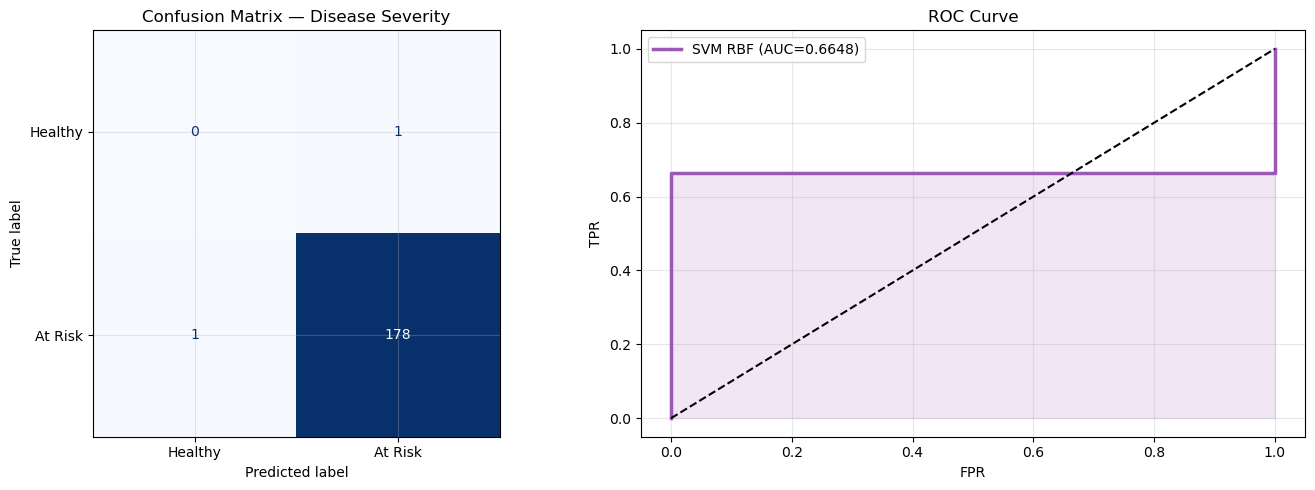

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.00      0.00      0.00         1
     At Risk       0.99      0.99      0.99       179

    accuracy                           0.99       180
   macro avg       0.50      0.50      0.50       180
weighted avg       0.99      0.99      0.99       180



In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_med = confusion_matrix(y_med_te, med_pred)
ConfusionMatrixDisplay(cm_med, display_labels=['Healthy','At Risk']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix — Disease Severity')

fpr_m, tpr_m, _ = roc_curve(y_med_te, med_prob)
auc_m = roc_auc_score(y_med_te, med_prob)
axes[1].plot(fpr_m, tpr_m, color=COLORS['tertiary'], linewidth=2.5,
             label=f'SVM RBF (AUC={auc_m:.4f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=1.5)
axes[1].fill_between(fpr_m, tpr_m, alpha=0.15, color=COLORS['tertiary'])
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Classification Report:')
print(classification_report(y_med_te, med_pred, target_names=['Healthy','At Risk']))

## 12. Final Summary & Key Takeaways

In [12]:
print('=' * 66)
print('          SUPPORT VECTOR MACHINE - KEY TAKEAWAYS')
print('=' * 66)

takeaways = [
    ('Core idea',        'Find hyperplane that maximizes margin between classes'),
    ('Support vectors',  'Only boundary points that define the hyperplane'),
    ('C parameter',      'Small C=wide margin/regularized, Large C=narrow/may overfit'),
    ('Kernel trick',     'Maps data to higher dimensions without computing it explicitly'),
    ('RBF kernel',       'Most powerful general-purpose kernel — controlled by gamma'),
    ('gamma',            'Small=smooth boundary, Large=complex/overfitting boundary'),
    ('Feature scaling',  'ALWAYS required — SVM is sensitive to feature magnitudes'),
    ('SVR epsilon',      'Errors inside the epsilon-tube are ignored (insensitive loss)'),
    ('Probability',      'Set probability=True for predict_proba (uses Platt scaling)'),
    ('Strength',         'Excellent in high-dim spaces, effective with clear margins'),
    ('Weakness',         'Slow on large datasets (O(n^2) to O(n^3)), hard to interpret'),
    ('Tuning',           'Always tune C and gamma together via GridSearchCV'),
]

for topic, detail in takeaways:
    print(f'  OK  {topic:<18}  ->  {detail}')

print('=' * 66)

          SUPPORT VECTOR MACHINE - KEY TAKEAWAYS
  OK  Core idea           ->  Find hyperplane that maximizes margin between classes
  OK  Support vectors     ->  Only boundary points that define the hyperplane
  OK  C parameter         ->  Small C=wide margin/regularized, Large C=narrow/may overfit
  OK  Kernel trick        ->  Maps data to higher dimensions without computing it explicitly
  OK  RBF kernel          ->  Most powerful general-purpose kernel — controlled by gamma
  OK  gamma               ->  Small=smooth boundary, Large=complex/overfitting boundary
  OK  Feature scaling     ->  ALWAYS required — SVM is sensitive to feature magnitudes
  OK  SVR epsilon         ->  Errors inside the epsilon-tube are ignored (insensitive loss)
  OK  Probability         ->  Set probability=True for predict_proba (uses Platt scaling)
  OK  Strength            ->  Excellent in high-dim spaces, effective with clear margins
  OK  Weakness            ->  Slow on large datasets (O(n^2) to O(n^3))

---
## Practice Exercises

1. **Compare all kernels** (linear, rbf, poly, sigmoid) on the moons dataset using a bar chart of test accuracies.
2. **Tune C and gamma jointly** on the medical dataset using GridSearchCV and plot the heatmap.
3. **Plot the number of support vectors** as C increases — what pattern do you see?
4. **Add a multiclass problem** (3 classes) and observe how SVC uses One-vs-One internally.
5. **Compare SVM vs Logistic Regression vs Random Forest** on the same dataset.
6. **Implement a linear SVM from scratch** using the hinge loss and gradient descent.

---
*Notebook created for the ML Repository — SVM module.*